Task 1.1

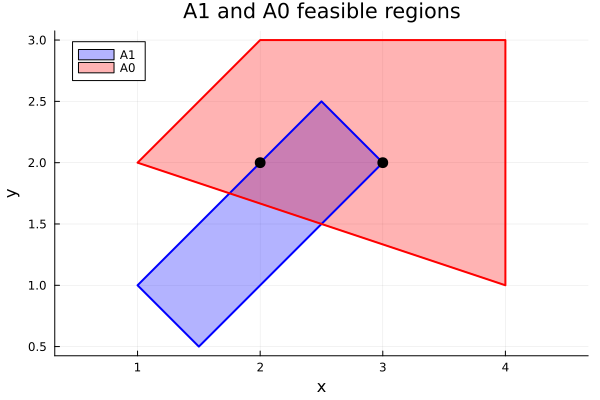

In [1]:
using Plots
using Statistics

# -----------------------------
# A1 vertices (bounded)
# -----------------------------
A1_vertices = [
    (1.0, 1.0),
    (1.5, 0.5),
    (3.0, 2.0),
    (2.5, 2.5)
]

# -----------------------------
# A0 vertices (clipped view)
# -----------------------------
A0_vertices = [
    (1.0, 2.0),
    (2.0, 3.0),
    (4.0, 3.0),
    (4.0, 1.0)
]

# helper to sort vertices counterclockwise
function sort_vertices(vertices)
    cx = mean(first.(vertices))
    cy = mean(last.(vertices))
    sort(vertices, by = p -> atan(p[2] - cy, p[1] - cx))
end

# sort and close polygons
function polygon_coords(vertices)
    v = sort_vertices(vertices)
    x = [p[1] for p in v]
    y = [p[2] for p in v]
    push!(x, v[1][1])
    push!(y, v[1][2])
    return x, y
end

A1x, A1y = polygon_coords(A1_vertices)
A0x, A0y = polygon_coords(A0_vertices)

# -----------------------------
# Plot both
# -----------------------------
plot(
    A1x, A1y,
    seriestype = :shape,
    alpha = 0.3,
    color = :blue,
    label = "A1 ",
    aspect_ratio = :equal,
    xlabel = "x",
    ylabel = "y",
    title = "A1 and A0 feasible regions",
    legend = :topleft
)

plot!(A0x, A0y,
    seriestype = :shape,
    alpha = 0.3,
    color = :red,
    label = "A0"
)

# draw borders for clarity
plot!(A1x, A1y, color=:blue, lw=2, label="")
plot!(A0x, A0y, color=:red, lw=2, label="")

# -----------------------------
# Optional: integer points (full model)
# -----------------------------
function feasible_all(x, y)
    # A1
    x + y >= 2 &&
    x + y <= 5 &&
    x - y >= 0 &&
    x - y <= 1 &&
    # A0
    y <= 3 &&
    x - y >= -1 &&
    x <= 4 &&
    (1/3)*x + y >= 7/3
end

pts = [(i, j) for i in -1:5 for j in -1:5 if feasible_all(i, j)]
xs = first.(pts)
ys = last.(pts)

scatter!(xs, ys, color=:black, markersize=6, label="")

display(current())

Task 1.2

In [2]:
using JuMP
using HiGHS
import MathOptInterface as MOI

model = Model(HiGHS.Optimizer)
@variable(model, lambda[1:4] >= 0)

@objective(model, Max,
    3*lambda[1] + 4*lambda[2] + 6*lambda[3] + 7*lambda[4]
)
# y <= 3
@constraint(model,
    lambda[1] + lambda[2] + 2*lambda[3] + 2*lambda[4] <= 3
)
# x <= 4
@constraint(model,
    lambda[1] + 2*lambda[2] + 2*lambda[3] + 3*lambda[4] <= 4
)
# (1/3)x + y >= 7/3   ->   4λ1 + 5λ2 + 8λ3 + 9λ4 >= 7
@constraint(model,
    4*lambda[1] + 5*lambda[2] + 8*lambda[3] + 9*lambda[4] >= 7
)
# convex combination
@constraint(model,
    lambda[1] + lambda[2] + lambda[3] + lambda[4] == 1
)
optimize!(model)
if termination_status(model) == MOI.OPTIMAL
    println("Objective value: ", objective_value(model))
    println("lambda = ", value.(lambda))
    x_val = value(lambda[1]) + 2*value(lambda[2]) + 2*value(lambda[3]) + 3*value(lambda[4])
    y_val = value(lambda[1]) + value(lambda[2]) + 2*value(lambda[3]) + 2*value(lambda[4])
    println("x = ", x_val)
    println("y = ", y_val)
else
    println("Optimize was not successful", termination_status(model))
end

Running HiGHS 1.8.0 (git hash: fcfb53414): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 9e+00]
  Cost   [3e+00, 7e+00]
  Bound  [0e+00, 0e+00]
  RHS    [1e+00, 7e+00]
Presolving model
4 rows, 4 cols, 16 nonzeros  0s
4 rows, 4 cols, 16 nonzeros  0s
Presolve : Reductions: rows 4(-0); columns 4(-0); elements 16(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -6.7499852191e+00 Ph1: 4(15.875); Du: 4(6.74999) 0s
          4     7.0000000000e+00 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 4
Objective value     :  7.0000000000e+00
HiGHS run time      :          0.00
Objective value: 7.0
lambda = [0.0, 0.0, 0.0, 1.0]
x = 3.0
y = 2.0


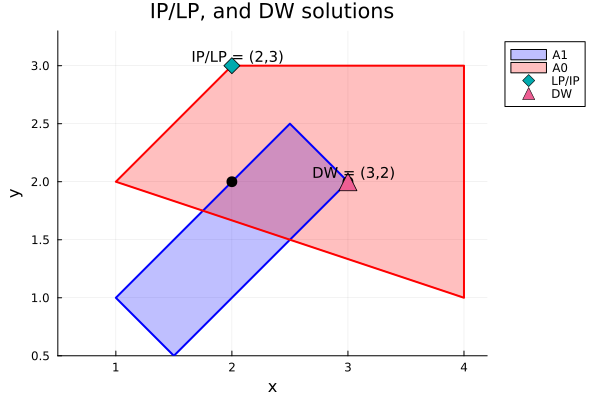

In [3]:
# -----------------------------
# Known solutions
# -----------------------------
ip_sol = (2.0, 3.0)
lp_sol = (2.0, 3.0)
dw_sol = (3.0, 2.0)

# -----------------------------
# Base plot
# -----------------------------
plot(
    A1x, A1y,
    seriestype = :shape,
    alpha = 0.25,
    color = :blue,
    label = "A1",
    aspect_ratio = :equal,
    xlabel = "x",
    ylabel = "y",
    title = "IP/LP, and DW solutions",
    xlims = (0.5, 4.2),
    ylims = (0.5, 3.3),
    legend = :outertopright
)

plot!(A0x, A0y,
    seriestype = :shape,
    alpha = 0.25,
    color = :red,
    label = "A0"
)

plot!(A1x, A1y, color = :blue, lw = 2, label = "")
plot!(A0x, A0y, color = :red, lw = 2, label = "")

scatter!(xs, ys,
    color = :black,
    markersize = 6,
    label = ""
)

# -----------------------------
# Add solution points
# -----------------------------
scatter!([lp_sol[1]], [lp_sol[2]],
    markershape = :diamond,
    markersize = 8,
    label = "LP/IP"
)

scatter!([dw_sol[1]], [dw_sol[2]],
    markershape = :utriangle,
    markersize = 9,
    label = "DW"
)

# Labels next to points
annotate!(ip_sol[1] + 0.05, ip_sol[2] + 0.08, text("IP/LP = (2,3)", 10))
annotate!(dw_sol[1] + 0.05, dw_sol[2] + 0.08, text("DW = (3,2)", 10))

display(current())

Task 2.1

In [4]:
using JuMP
using HiGHS
import MathOptInterface as MOI

w = [
     2  3  1  6  7
     3  4  3  7  6
     4  7  7  4  6
]

p = [
     1  7  3  8  6
     1  4  4  7  9
     7  2  3  3  7
]

cap = [35, 34, 33]
K = [(2,4), (3,4)]

Machines = 1:3
Jobs = 1:5

model = Model(HiGHS.Optimizer)

@variable(model, x[i in Machines, j in Jobs], Bin)

@objective(model, Max, sum(p[i, j] * x[i, j] for i in Machines, j in Jobs))

@constraint(model, [j in Jobs], sum(x[i, j] for i in Machines) == 1)

@constraint(model, [i in Machines], sum(w[i, j] * x[i, j] for j in Jobs) <= cap[i])

@constraint(model, [i in Machines, (a,b) in K], x[i, a] + x[i, b] <= 1)

optimize!(model)

if termination_status(model) == MOI.OPTIMAL
    println("Objective value = ", objective_value(model))
    for j in Jobs
        for i in Machines
            if value(x[i, j]) > 0.5
                println("Job $j assigned to machine $i")
            end
        end
    end
else
    println("Solver status: ", termination_status(model))
end

Running HiGHS 1.8.0 (git hash: fcfb53414): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 7e+00]
  Cost   [1e+00, 9e+00]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 4e+01]
Presolving model
11 rows, 15 cols, 27 nonzeros  0s
9 rows, 10 cols, 21 nonzeros  0s
9 rows, 9 cols, 21 nonzeros  0s
Objective function is integral with scale 1

Solving MIP model with:
   9 rows
   9 cols (9 binary, 0 integer, 0 implied int., 0 continuous)
   21 nonzeros

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   38              -inf                 inf        0      0      0         0     0.0s
 T       0       0         0   0.00%   38              33                15.15%        0      0      0         5     0.0s
         1       0         1 1

Task 2.2